<a href="https://colab.research.google.com/github/cacjr/ML-Modelagem-Avancada-Tuning-e-Interpretabilidade/blob/main/Sprint3_FIAP_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Sprint 3 – Modelagem Avançada, Tuning e Interpretabilidade
## FIAP – Machine Learning

---

### Integrantes
- Claudio Alves
- Rodrigo Wolkoff
- Luna Rousseau
- Mario Oliveira
- Vinicius Silva

---

# Objetivo da Sprint

Nesta Sprint 3, o foco foi elevar a maturidade da solução de Machine Learning desenvolvida anteriormente, incorporando:

- Feature Engineering avançado
- Comparação entre múltiplos modelos
- Tuning de hiperparâmetros
- Validação robusta com TimeSeriesSplit
- Avaliação com métricas estatísticas
- Interpretabilidade utilizando SHAP
- Visualizações analíticas

---

# Contexto do Problema

O objetivo do projeto é prever o número de visitantes do parque Korkeasaari utilizando informações históricas e temporais.

Trata-se de um problema de regressão com características de série temporal, exigindo cuidados específicos para evitar vazamento temporal.


# 1. Importação das Bibliotecas

In [ ]:

# =========================
# IMPORTAÇÃO DAS BIBLIOTECAS
# =========================

# Instalação
!pip install optuna -q
!pip install shap -q
!pip install xgboost -q

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

# Validação e tuning
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit,
    cross_val_score
)

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Interpretabilidade
import shap

# Otimização Bayesiana
import optuna

# Configuração visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

print('Bibliotecas carregadas com sucesso.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.6 MB/s eta 0:00:00
Bibliotecas carregadas com sucesso.



## Explicação Teórica

As bibliotecas utilizadas foram escolhidas para atender cada etapa do pipeline de Machine Learning:

- Pandas e NumPy → manipulação de dados
- Matplotlib e Seaborn → visualizações
- Scikit-Learn → modelagem e métricas
- XGBoost → boosting otimizado
- Optuna → tuning bayesiano
- SHAP → interpretabilidade


# 2. Carregamento dos Dados

In [ ]:

# Conectando ao drive para acessar o dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# =========================
# CARREGAMENTO DO DATASET
# =========================

# O Excel possui:
# linha 0 = título
# linha 1 = cabeçalho verdadeiro

df = pd.read_excel(
    '/content/drive/MyDrive/Korkeasaari_Visitor_Statistics.xlsx',
    skiprows=1
)

# Visualização inicial
df.head()


,Year,Ferry / Water Bus\n(North Shore / Market Sq.),Water Bus\n(Hakaniemi / Market Sq.),Bridge\n(Mustikkamaa),Water Transport\nTotal,Grand Total\nVisitors,Water Transport\nShare (%),Bridge\nShare (%),Notes
0,1955,382785.0,12468.0,NaN,395253.0,395253,1.0,0.0,NaN
1,1956,301625.0,21151.0,NaN,322776.0,322776,1.0,0.0,NaN
2,1957,284610.0,19400.0,NaN,304010.0,304010,1.0,0.0,NaN
3,1958,270089.0,29700.0,NaN,299789.0,299789,1.0,0.0,NaN
4,1959,298198.0,74308.0,NaN,372506.0,372506,1.0,0.0,NaN


# 3. Padronização e Limpeza

In [ ]:

# =========================
# PADRONIZAÇÃO DAS COLUNAS
# =========================

# Limpeza dos nomes
df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.replace('\n', ' ')
)

# Visualizar colunas
print(df.columns.tolist())

# Renomear automaticamente
rename_map = {}

for col in df.columns:

    col_lower = col.lower()

    if 'year' in col_lower:
        rename_map[col] = 'Year'

    elif 'visitor' in col_lower:
        rename_map[col] = 'Visitors'

    elif 'note' in col_lower:
        rename_map[col] = 'Notes'

df = df.rename(columns=rename_map)

print(df.columns)

# Conversão de tipos
df['Year'] = pd.to_numeric(
    df['Year'],
    errors='coerce'
)

df['Visitors'] = pd.to_numeric(
    df['Visitors'],
    errors='coerce'
)

# Remover inválidos
df = df.dropna(
    subset=['Year', 'Visitors']
)

# Ajuste de tipos
df['Year'] = df['Year'].astype(int)

df.head()


['Year', 'Ferry / Water Bus (North Shore / Market Sq.)', 'Water Bus (Hakaniemi / Market Sq.)', 'Bridge (Mustikkamaa)', 'Water Transport Total', 'Grand Total Visitors', 'Water Transport Share (%)', 'Bridge Share (%)', 'Notes']
Index(['Year', 'Ferry / Water Bus (North Shore / Market Sq.)',
       'Water Bus (Hakaniemi / Market Sq.)', 'Bridge (Mustikkamaa)',
       'Water Transport Total', 'Visitors', 'Water Transport Share (%)',
       'Bridge Share (%)', 'Notes'],
      dtype='object')


,Year,Ferry / Water Bus (North Shore / Market Sq.),Water Bus (Hakaniemi / Market Sq.),Bridge (Mustikkamaa),Water Transport Total,Visitors,Water Transport Share (%),Bridge Share (%),Notes
0,1955,382785.0,12468.0,NaN,395253.0,395253,1.0,0.0,NaN
1,1956,301625.0,21151.0,NaN,322776.0,322776,1.0,0.0,NaN
2,1957,284610.0,19400.0,NaN,304010.0,304010,1.0,0.0,NaN
3,1958,270089.0,29700.0,NaN,299789.0,299789,1.0,0.0,NaN
4,1959,298198.0,74308.0,NaN,372506.0,372506,1.0,0.0,NaN



## Explicação

Essa etapa foi necessária porque o arquivo Excel apresentava:

- cabeçalho deslocado
- quebras de linha
- nomes inconsistentes

A padronização garante maior robustez do pipeline.


# 4. Feature Engineering


## Fundamentação Teórica

Feature Engineering permite representar padrões temporais e históricos que auxiliam os modelos a aprender relações mais complexas.

Foram criadas variáveis relacionadas a:

- tendência temporal
- memória histórica
- eventos extraordinários
- médias móveis
- crescimento percentual


In [ ]:

# =========================
# FEATURE ENGINEERING
# =========================

# Década
df['Decade'] = (
    df['Year'] // 10
) * 10

# Tempo desde início da série
df['Years_Since_Start'] = (
    df['Year'] - df['Year'].min()
)

# Evento histórico
df['Bridge_Opened_1974'] = (
    df['Notes']
    .apply(
        lambda x: 1 if 'bridge' in str(x).lower() else 0
    )
)

# Pandemia
df['COVID_2020'] = (
    df['Notes']
    .apply(
        lambda x: 1 if 'covid' in str(x).lower() else 0
    )
)

# Lag temporal
df['Prev_Year_Visitors'] = (
    df['Visitors'].shift(1)
)

# Lag 2 anos
df['Lag_2_Visitors'] = (
    df['Visitors'].shift(2)
)

# Média móvel
df['Rolling_Mean_3'] = (
    df['Visitors']
    .rolling(window=3)
    .mean()
)

# Crescimento percentual
df['Growth_Rate'] = (
    df['Visitors']
    .pct_change()
)

# Remover linhas inválidas
df = df.dropna(
    subset=[
        'Prev_Year_Visitors',
        'Lag_2_Visitors'
    ]
).reset_index(drop=True)

df.head()


,Year,Ferry / Water Bus (North Shore / Market Sq.),Water Bus (Hakaniemi / Market Sq.),Bridge (Mustikkamaa),Water Transport Total,Visitors,Water Transport Share (%),Bridge Share (%),Notes,Decade,Years_Since_Start,Bridge_Opened_1974,COVID_2020,Prev_Year_Visitors,Lag_2_Visitors,Rolling_Mean_3,Growth_Rate
0,1957,284610.0,19400.0,NaN,304010.0,304010,1.0,0.0,NaN,1950,2,0,0,322776.0,395253.0,340679.666667,-0.058139
1,1958,270089.0,29700.0,NaN,299789.0,299789,1.0,0.0,NaN,1950,3,0,0,304010.0,322776.0,308858.333333,-0.013884
2,1959,298198.0,74308.0,NaN,372506.0,372506,1.0,0.0,NaN,1950,4,0,0,299789.0,304010.0,325435.000000,0.242561
3,1960,294341.0,65843.0,NaN,360184.0,360184,1.0,0.0,NaN,1960,5,0,0,372506.0,299789.0,344159.666667,-0.033079
4,1961,276149.0,62800.0,NaN,338949.0,338949,1.0,0.0,NaN,1960,6,0,0,360184.0,372506.0,357213.000000,-0.058956



## Justificativa das Features

### Prev_Year_Visitors
Captura dependência temporal entre anos consecutivos.

### Rolling_Mean_3
Representa tendência suavizada da série.

### COVID_2020
Representa ruptura estrutural causada pela pandemia.

### Growth_Rate
Captura aceleração ou desaceleração do crescimento.


# 5. Análise Exploratória

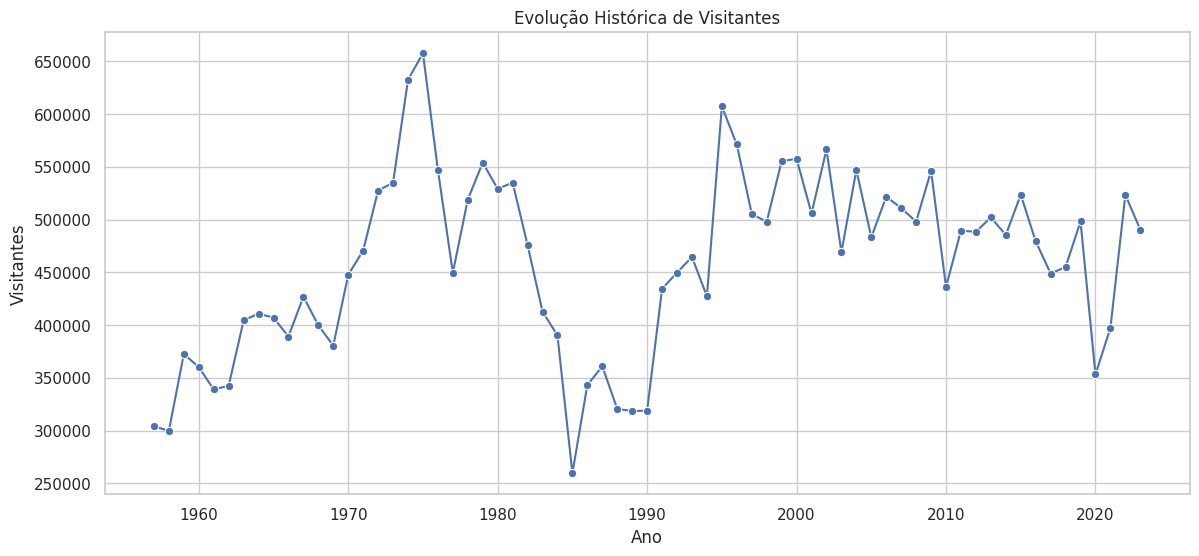

In [ ]:

plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='Year',
    y='Visitors',
    marker='o'
)

plt.title('Evolução Histórica de Visitantes')
plt.xlabel('Ano')
plt.ylabel('Visitantes')

plt.show()


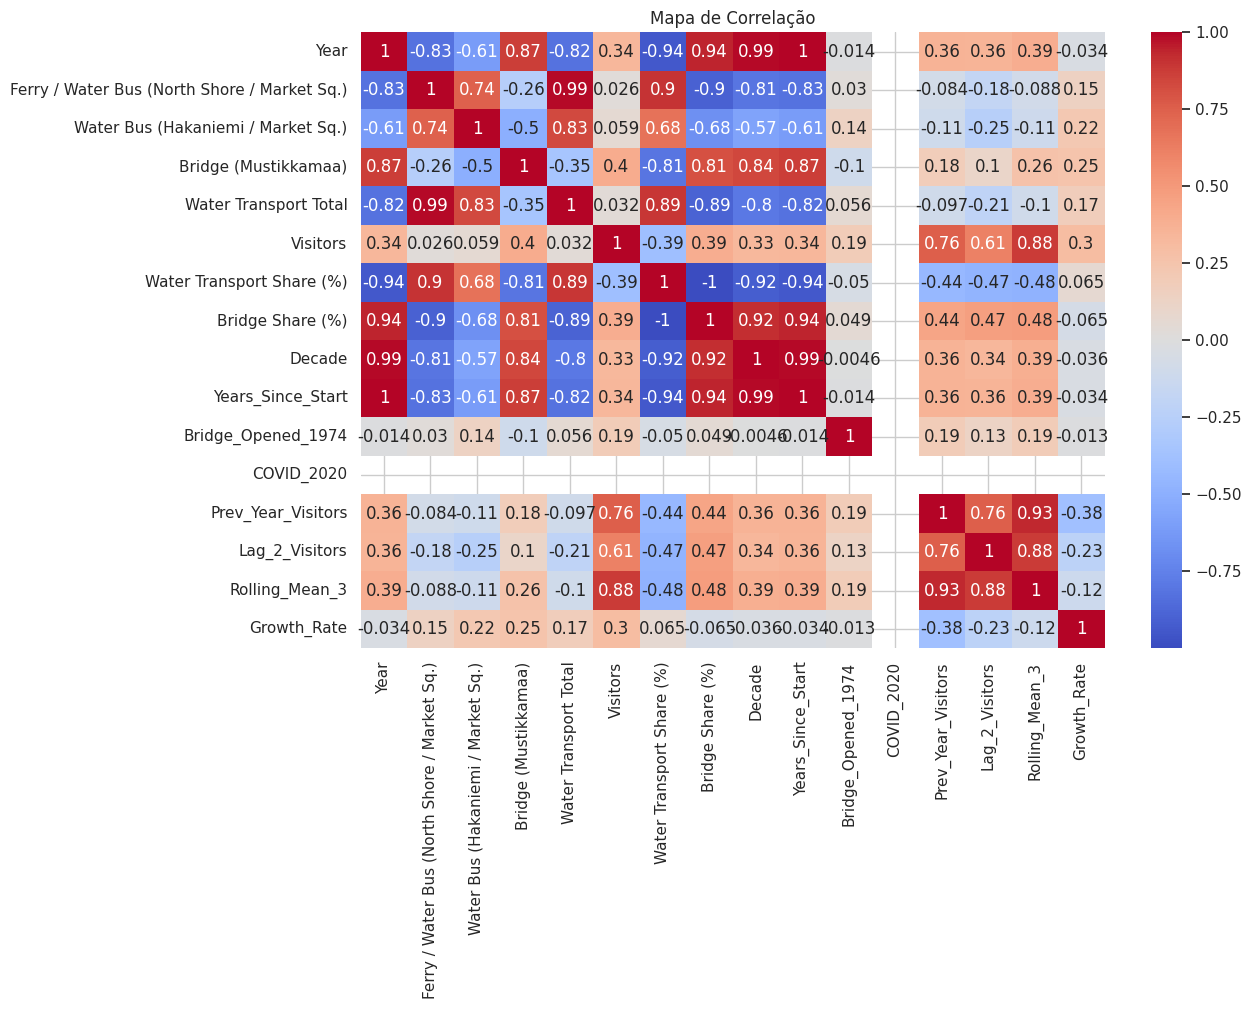

In [ ]:

plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Mapa de Correlação')

plt.show()



## Interpretação

As variáveis temporais demonstraram forte correlação com o target, especialmente:

- Prev_Year_Visitors
- Rolling_Mean_3

Isso indica forte dependência histórica na série temporal.


# 6. Definição das Features

In [ ]:

features = [
    'Year',
    'Decade',
    'Years_Since_Start',
    'Bridge_Opened_1974',
    'COVID_2020',
    'Prev_Year_Visitors',
    'Lag_2_Visitors',
    'Rolling_Mean_3',
    'Growth_Rate'
]

X = df[features]

y = df['Visitors']

print(features)


['Year', 'Decade', 'Years_Since_Start', 'Bridge_Opened_1974', 'COVID_2020', 'Prev_Year_Visitors', 'Lag_2_Visitors', 'Rolling_Mean_3', 'Growth_Rate']


# 7. Separação Train e Test


## Fundamentação

Como se trata de série temporal, utilizamos divisão cronológica.

Isso evita vazamento temporal e garante maior realismo na avaliação.


In [ ]:

split_index = int(len(df) * 0.7)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)


print('\nDiagnóstico do dataset:')
print('Dataset:', df.shape)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)


(46, 9)
(21, 9)

Diagnóstico do dataset:
Dataset: (67, 17)
X_train: (46, 9)
X_test: (21, 9)
y_train: (46,)
y_test: (21,)


# 8. Modelagem


## Modelos Utilizados

- Random Forest
- Gradient Boosting
- XGBoost


In [ ]:

models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    r2 = r2_score(y_test, preds)

    results.append([
        name,
        mae,
        rmse,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=['Modelo', 'MAE', 'RMSE', 'R2']
)

results_df


,Modelo,MAE,RMSE,R2
0,Random Forest,39802.787619,45181.618233,0.006850
1,Gradient Boosting,34347.581212,39260.675277,0.250094
2,XGBoost,42395.531250,47514.011744,-0.098335


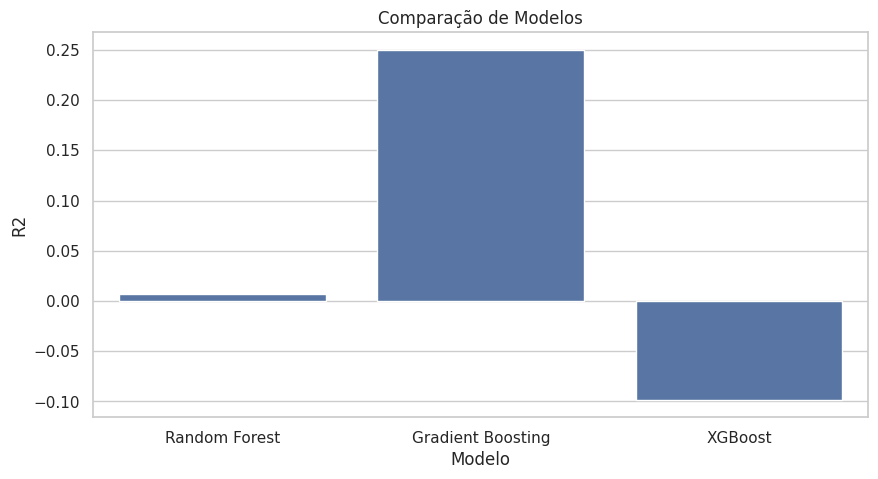

In [ ]:

plt.figure(figsize=(10,5))

sns.barplot(
    data=results_df,
    x='Modelo',
    y='R2'
)

plt.title('Comparação de Modelos')

plt.show()


# 9. Tuning de Hiperparâmetros


Foram utilizadas três estratégias diferentes:

- GridSearchCV
- RandomizedSearchCV
- Optuna


In [ ]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(rf_grid.best_params_)


{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [ ]:

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print(rf_random.best_params_)


{'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 5}


In [ ]:

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int(
            'n_estimators', 100, 500
        ),
        'max_depth': trial.suggest_int(
            'max_depth', 3, 15
        ),
        'min_samples_split': trial.suggest_int(
            'min_samples_split', 2, 10
        )
    }

    model = RandomForestRegressor(
        random_state=42,
        **params
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=TimeSeriesSplit(n_splits=5),
        scoring='r2'
    )

    return scores.mean()

study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=30
)

print(study.best_params)


[I 2026-05-03 03:58:03,209] A new study created in memory with name: no-name-d5c35308-51ac-4ada-9579-c6023310757c
[I 2026-05-03 03:58:04,862] Trial 0 finished with value: -1.0051753121416278 and parameters: {'n_estimators': 165, 'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: -1.0051753121416278.
[I 2026-05-03 03:58:07,592] Trial 1 finished with value: -0.5781887447009477 and parameters: {'n_estimators': 256, 'max_depth': 11, 'min_samples_split': 6}. Best is trial 1 with value: -0.5781887447009477.
[I 2026-05-03 03:58:09,232] Trial 2 finished with value: -0.9773570522390415 and parameters: {'n_estimators': 234, 'max_depth': 6, 'min_samples_split': 10}. Best is trial 1 with value: -0.5781887447009477.
[I 2026-05-03 03:58:10,489] Trial 3 finished with value: -0.9832780889214068 and parameters: {'n_estimators': 201, 'max_depth': 7, 'min_samples_split': 10}. Best is trial 1 with value: -0.5781887447009477.
[I 2026-05-03 03:58:13,576] Trial 4 finished with value: -0.54

{'n_estimators': 334, 'max_depth': 11, 'min_samples_split': 4}


In [ ]:

comparison_tuning = pd.DataFrame({
    'Método': [
        'GridSearch',
        'RandomizedSearch',
        'Optuna'
    ],
    'Score': [
        rf_grid.best_score_,
        rf_random.best_score_,
        study.best_value
    ]
})

comparison_tuning


,Método,Score
0,GridSearch,-0.535109
1,RandomizedSearch,-0.508733
2,Optuna,-0.501908


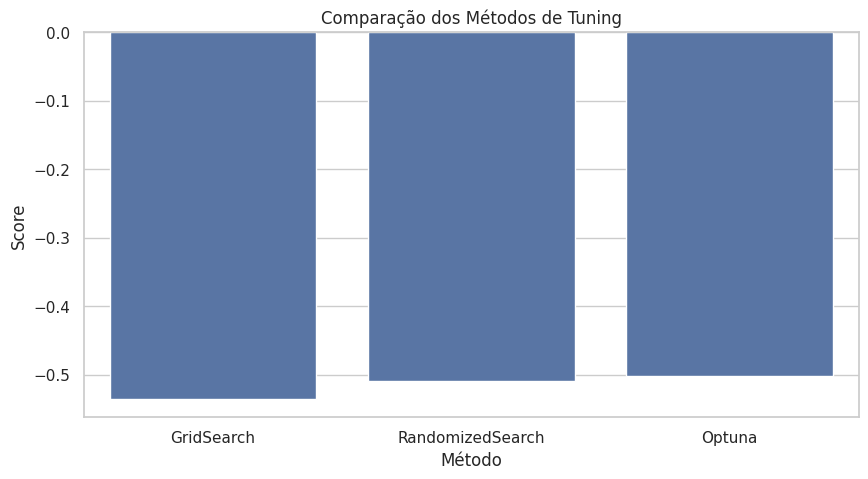

In [ ]:

plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_tuning,
    x='Método',
    y='Score'
)

plt.title('Comparação dos Métodos de Tuning')

plt.show()


# 10. Validação Robusta


Utilizamos TimeSeriesSplit para respeitar a ordem cronológica dos dados.


In [ ]:

best_model = RandomForestRegressor(
    random_state=42,
    **study.best_params
)

tscv = TimeSeriesSplit(n_splits=5)

cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=tscv,
    scoring='r2'
)

print(cv_scores)
print(cv_scores.mean())
print(cv_scores.std())


[-0.8285213   0.03188562 -2.63759333  0.65023781  0.27445182]
-0.5019078743015821
1.173280722390596


# 11. Modelo Final

In [ ]:

best_model.fit(X_train, y_train)

final_preds = best_model.predict(X_test)


# 12. Avaliação Final

In [ ]:

mae = mean_absolute_error(
    y_test,
    final_preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_preds
    )
)

r2 = r2_score(
    y_test,
    final_preds
)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')


MAE: 38336.75
RMSE: 44206.41
R²: 0.0493


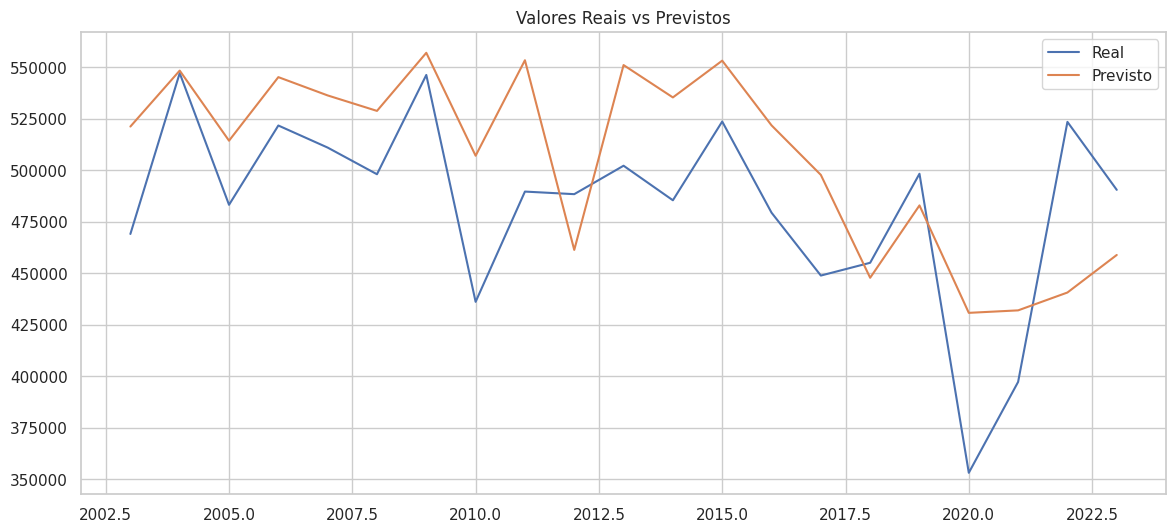

In [ ]:

results_plot = pd.DataFrame({
    'Ano': df.iloc[split_index:]['Year'],
    'Real': y_test.values,
    'Previsto': final_preds
})

plt.figure(figsize=(14,6))

plt.plot(
    results_plot['Ano'],
    results_plot['Real'],
    label='Real'
)

plt.plot(
    results_plot['Ano'],
    results_plot['Previsto'],
    label='Previsto'
)

plt.title('Valores Reais vs Previstos')

plt.legend()

plt.show()


# 13. Análise Residual

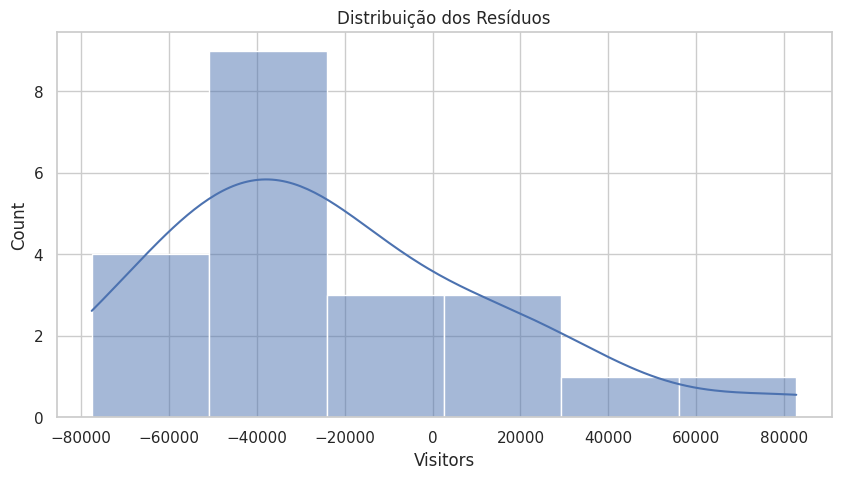

In [ ]:

residuals = y_test - final_preds

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title('Distribuição dos Resíduos')

plt.show()


# 14. Interpretabilidade com SHAP


O SHAP permite compreender quais variáveis mais influenciam as previsões do modelo.


In [ ]:

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)


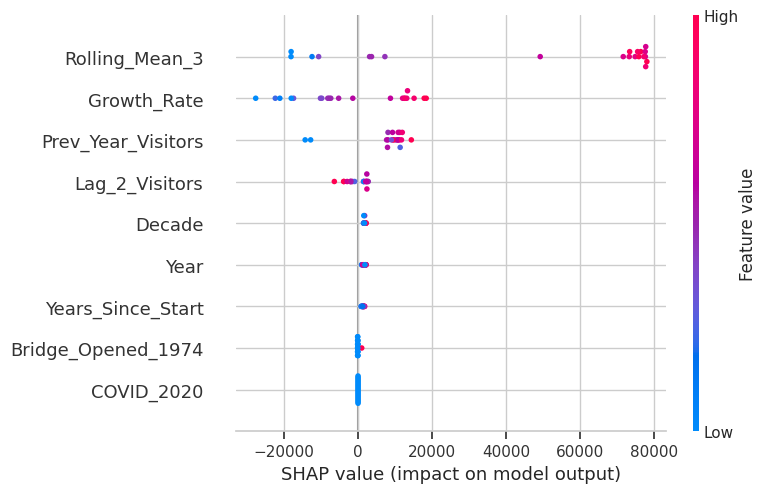

In [ ]:

shap.summary_plot(
    shap_values,
    X_test
)


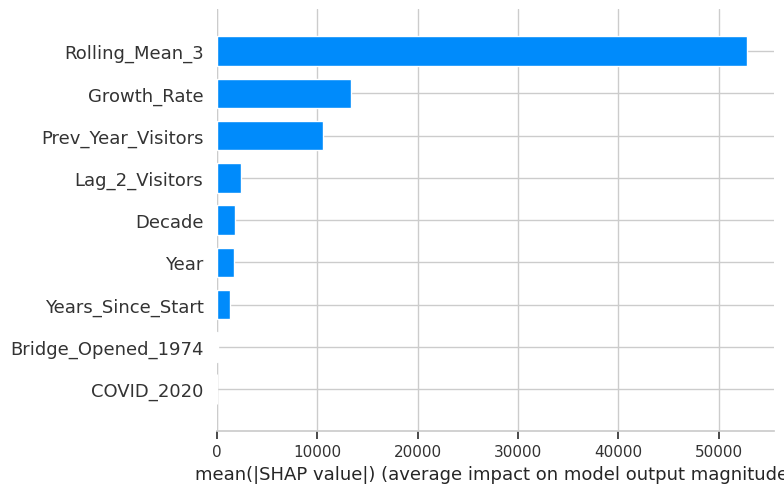

In [ ]:

shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)


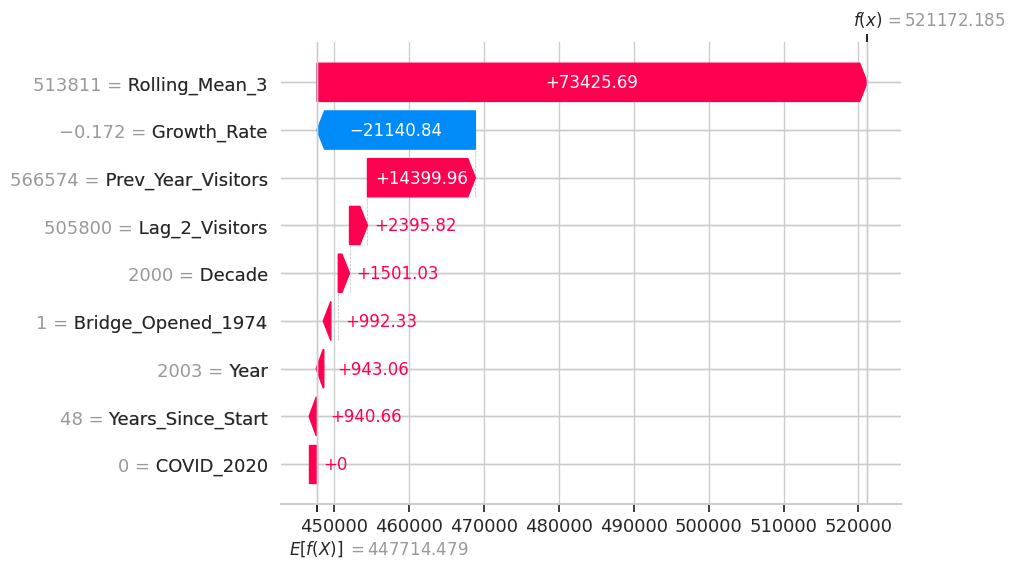

In [ ]:

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)


# 15. Conclusão


Nesta Sprint 3 foi possível evoluir significativamente a solução de Machine Learning.

Os principais avanços foram:

- Feature Engineering avançado
- Tuning robusto
- Comparação entre modelos
- Validação temporal adequada
- Interpretabilidade com SHAP

As features temporais demonstraram forte relevância preditiva, especialmente variáveis relacionadas à memória histórica da série.

Além disso, a utilização do SHAP aumentou a transparência e interpretabilidade do modelo final.

---

## Melhorias Futuras

Como evolução futura, poderiam ser adicionados:

- LightGBM
- Redes neurais LSTM
- Variáveis climáticas
- Dados externos de turismo

Esses dados e tecnologias ajudariam muito a avançar em relação a predição e qualidade da solução.
